# US-3.2 Regresiones y Correlaciones
**Proyecto:** ConAIgua  
**Sprint:** 3  
**Objetivo:** Implementar y validar módulo de modelado estadístico con regresión lineal/múltiple y correlaciones Pearson/Spearman.

In [1]:
# ── Celda 1: Setup ──────────────────────────────
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_parquet('../data/processed/conAIgua_dataframe.parquet')
df_25001 = df[df['estacion_id'] == '25001']
print(f'Registros estación 25001: {len(df_25001)}')
print(f'Columnas: {df_25001.columns.tolist()}')

Registros estación 25001: 19574
Columnas: ['estacion_id', 'nombre_estacion', 'estado', 'municipio', 'situacion_estacion', 'organismo', 'cve_omm', 'latitud', 'longitud', 'altitud_msnm', 'fecha', 'precip', 'evap', 'tmax', 'tmin', 'anio', 'mes', 'dia']


## 1. Correlación Pearson y Spearman

In [2]:
# ── Celda 2: Correlación Pearson/Spearman ───────
from scripts.eda_engine.correlation import compute_correlations

result_corr = compute_correlations(df_25001, 'precip', 'tmax')
print('Correlación precipitación vs temperatura máxima:')
print(f"  Pearson:  r={result_corr['pearson']['r']}  p={result_corr['pearson']['p_value']}  sig={result_corr['pearson']['significativo']}")
print(f"  Spearman: r={result_corr['spearman']['r']}  p={result_corr['spearman']['p_value']}  sig={result_corr['spearman']['significativo']}")
print(f"  N obs: {result_corr['n_obs']}")

Correlación precipitación vs temperatura máxima:
  Pearson:  r=-0.0613  p=0.0  sig=True
  Spearman: r=-0.0224  p=0.0018  sig=True
  N obs: 19530


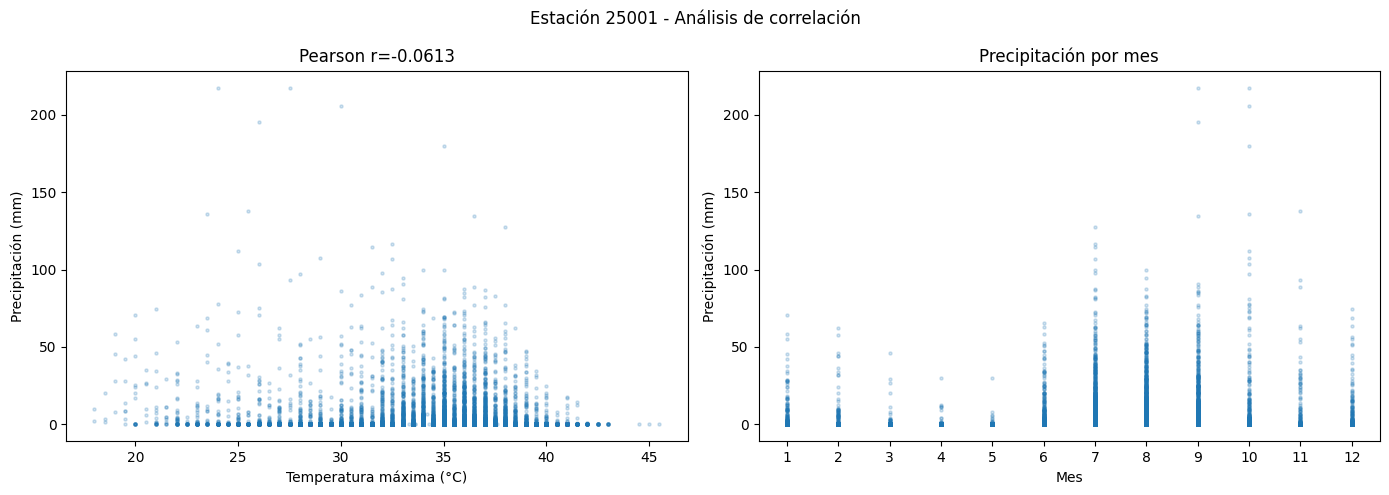

In [3]:
# ── Celda 3: Visualización correlación ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_25001['tmax'], df_25001['precip'], alpha=0.2, s=5)
axes[0].set_xlabel('Temperatura máxima (°C)')
axes[0].set_ylabel('Precipitación (mm)')
axes[0].set_title(f"Pearson r={result_corr['pearson']['r']}")

axes[1].scatter(df_25001['mes'], df_25001['precip'], alpha=0.2, s=5)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Precipitación (mm)')
axes[1].set_title('Precipitación por mes')
axes[1].set_xticks(range(1, 13))

plt.suptitle('Estación 25001 - Análisis de correlación')
plt.tight_layout()
plt.show()

## 2. Regresión Lineal Simple

In [4]:
# ── Celda 4: Regresión lineal simple ────────────
from scripts.eda_engine.regression import linear_regression

result_lr = linear_regression(df_25001, 'mes', 'precip')
print('Regresión lineal: precip ~ mes')
print(f"  Intercepto:  {result_lr['intercepto']}")
print(f"  Pendiente:   {result_lr['pendiente']}")
print(f"  R²:          {result_lr['r2']}")
print(f"  RMSE:        {result_lr['rmse']}")
print(f"  IC 95%:      {result_lr['intervalo_confianza_95']}")
print(f"  P-value:     {result_lr['p_value']}")
print(f"  Significativo: {result_lr['significativo']}")
print(f"  Diagnóstico: {result_lr['diagnostico']}")

Regresión lineal: precip ~ mes
  Intercepto:  0.4102
  Pendiente:   0.282
  R²:          0.0117
  RMSE:        8.9626
  IC 95%:      {'inferior': np.float64(0.2457), 'superior': np.float64(0.3184)}
  P-value:     0.0
  Significativo: True
  Diagnóstico: ajuste débil, modelo estadísticamente significativo (p=0.0)


c:\Users\chris\OneDrive\Escritorio\Python\Residencias\AgenteEDA\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


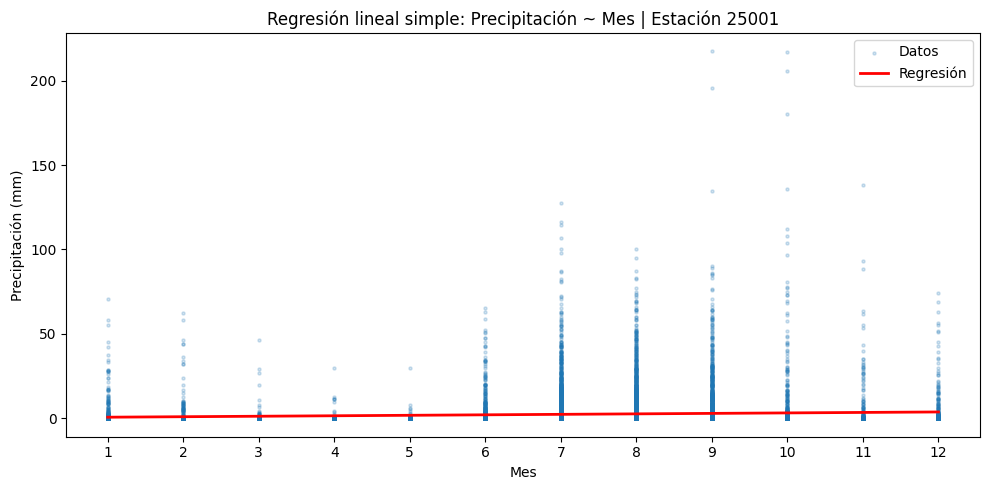

In [5]:
# ── Celda 5: Visualización regresión simple ─────
df_lr = df_25001[['mes', 'precip']].dropna()
model_lr = LinearRegression()
model_lr.fit(df_lr[['mes']], df_lr['precip'])

x_line = np.arange(1, 13).reshape(-1, 1)

plt.figure(figsize=(10, 5))
plt.scatter(df_lr['mes'], df_lr['precip'], alpha=0.2, s=5, label='Datos')
plt.plot(x_line, model_lr.predict(x_line), color='red', linewidth=2, label='Regresión')
plt.xlabel('Mes')
plt.ylabel('Precipitación (mm)')
plt.title('Regresión lineal simple: Precipitación ~ Mes | Estación 25001')
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()

## 3. Regresión Lineal Múltiple

In [6]:
# ── Celda 6: Regresión múltiple ─────────────────
from scripts.eda_engine.regression import multiple_regression

result_mr = multiple_regression(df_25001, ['mes', 'anio'], 'precip')
print('Regresión múltiple: precip ~ mes + anio')
print(f"  Intercepto:   {result_mr['intercepto']}")
print(f"  Coeficientes: {result_mr['coeficientes']}")
print(f"  R²:           {result_mr['r2']}")
print(f"  R² ajustado:  {result_mr['r2_ajustado']}")
print(f"  RMSE:         {result_mr['rmse']}")
print(f"  Diagnóstico:  {result_mr['diagnostico']}")

Regresión múltiple: precip ~ mes + anio
  Intercepto:   -8.3825
  Coeficientes: {'mes': 0.2824, 'anio': 0.0044}
  R²:           0.0118
  R² ajustado:  0.0117
  RMSE:         8.9623
  Diagnóstico:  ajuste débil


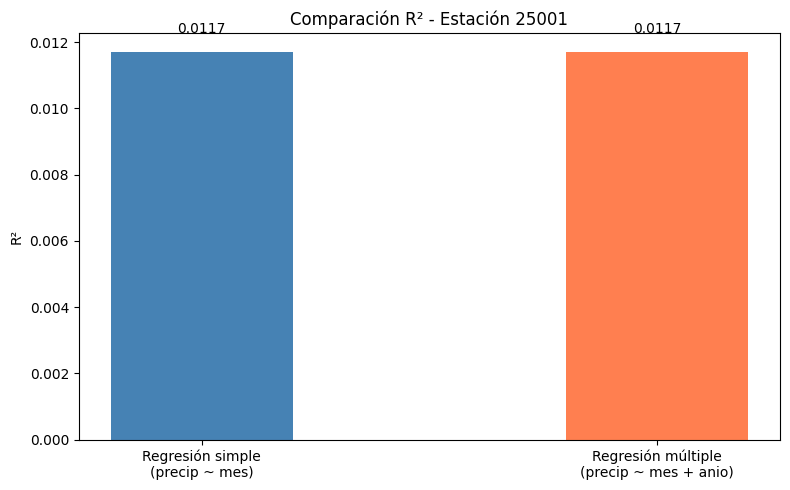

In [7]:
# ── Celda 7: Comparación R² simple vs múltiple ──
modelos = ['Regresión simple\n(precip ~ mes)', 'Regresión múltiple\n(precip ~ mes + anio)']
r2_vals = [result_lr['r2'], result_mr['r2_ajustado']]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, r2_vals, color=['steelblue', 'coral'], width=0.4)
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom')
plt.ylabel('R²')
plt.title('Comparación R² - Estación 25001')
plt.tight_layout()
plt.show()

## 4. Conclusiones

In [8]:
# ── Celda 8: Conclusiones ───────────────────────
print("""
Conclusiones US-3.2:

1. Correlación precip-tmax (Estación 25001):
   - Pearson  r=-0.0613: relación negativa muy débil
   - Spearman r=-0.0224: confirma relación débil
   - Ambas estadísticamente significativas por el alto n (~19k obs)

2. Regresión simple precip ~ mes:
   - R²=0.0117: el mes explica solo el 1.17% de la variabilidad
   - Pendiente positiva: precipitación aumenta hacia meses de verano
   - IC 95%: (0.2457, 0.3184) — pendiente significativa
   - Diagnóstico: ajuste débil pero estadísticamente significativo

3. Regresión múltiple precip ~ mes + anio:
   - R² ajustado=0.0117: agregar año no mejora el modelo
   - Coef anio=0.0044: tendencia anual prácticamente nula
   - La precipitación no presenta tendencia anual clara en esta estación
""")


Conclusiones US-3.2:

1. Correlación precip-tmax (Estación 25001):
   - Pearson  r=-0.0613: relación negativa muy débil
   - Spearman r=-0.0224: confirma relación débil
   - Ambas estadísticamente significativas por el alto n (~19k obs)

2. Regresión simple precip ~ mes:
   - R²=0.0117: el mes explica solo el 1.17% de la variabilidad
   - Pendiente positiva: precipitación aumenta hacia meses de verano
   - IC 95%: (0.2457, 0.3184) — pendiente significativa
   - Diagnóstico: ajuste débil pero estadísticamente significativo

3. Regresión múltiple precip ~ mes + anio:
   - R² ajustado=0.0117: agregar año no mejora el modelo
   - Coef anio=0.0044: tendencia anual prácticamente nula
   - La precipitación no presenta tendencia anual clara en esta estación

